# FSSK q=1 state validation against the mean-reverting Euler ODE

This notebook compares:

0. The `Lambda = 0` special case against `tensordev.core.Jax().tensor_path_signature`.
1. `volterra/fssk/state.py`: the exact q=1 finite-step recursion from `ii_part.tex` for piecewise linear paths.
2. An independent explicit Euler discretization of the mean-reverting tensor ODE from `i_part.tex`.

The comparison is done at the **Volterra-signature readout level**, not by directly comparing hidden states:

- `state.py` readout at current time: `1 + Z @ b`.
- ODE readout at current time: `1 + sum_l Z^l`.

For non-diagonal `Lambda`, the notebook also includes a transposed-drift diagnostic. The intended ODE convention is called `paper`.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import lax
from functools import partial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensordev.core import Jax
from tensordev.sss.kernel import FSSK
from tensordev.sss.state import StateSpaceSignature
from tensordev.sss.state_update import fssk_readout


## Tensor helper functions

The independent Euler state is represented levelwise as

```text
Z[n].shape == (R, m**n)
```

or, after scanning over coarse grid points,

```text
Z[n].shape == (S + 1, R, m**n).
```

In [2]:
def _dt_vector(dt, S: int, dtype):
    """Normalize scalar, length-1, or length-S dt to shape (S,)."""
    dt = jnp.asarray(dt, dtype=dtype)
    if dt.ndim == 0:
        return jnp.full((S,), dt, dtype=dtype)
    if dt.ndim == 1 and dt.shape[0] == 1:
        return jnp.full((S,), dt[0], dtype=dtype)
    if dt.ndim == 1 and dt.shape[0] == S:
        return dt
    raise ValueError(f"dt must be scalar, shape (1,), or shape ({S},), got {dt.shape}.")


def _zero_state(trunc: int, R: int, m: int, dtype):
    return tuple(jnp.zeros((R, m**n), dtype=dtype) for n in range(trunc + 1))


def _tensor_right_by_increment(a, dy):
    """Return a tensor dy, flattened in tensor coordinates."""
    return (a[..., :, None] * dy[None, :]).reshape(a.shape[:-1] + (a.shape[-1] * dy.shape[0],))


def _state_signature_readout_levels(Z):
    """ODE readout: 1 + sum_l Z^l, levelwise."""
    out = []
    for n, z in enumerate(Z):
        v = jnp.sum(z, axis=-2)  # sum over R
        if n == 0:
            v = v + jnp.ones_like(v)
        out.append(v)
    return tuple(out)


def _source_term(Z, dy, b, trunc: int):
    """Explicit-Euler source term: (1 + sum_l Z^l) tensor (b^ell dy)."""
    dtype = dy.dtype
    R = b.shape[0]

    sig = _state_signature_readout_levels(Z)
    src = [jnp.zeros((R, 1), dtype=dtype)]
    for n in range(1, trunc + 1):
        inc = _tensor_right_by_increment(sig[n - 1], dy)  # shape (m**n,)
        src.append(b[:, None] * inc[None, :])             # shape (R, m**n)
    return tuple(src)


def _drift_term(Z, Lambda_mat, drift_convention: str):
    """
    Mean-reversion drift.

    paper:
        out[ell] = -sum_k Lambda[ell, k] Z[k]
    state_right:
        out[ell] = -sum_k Lambda[k, ell] Z[k]
    """
    if drift_convention == "paper":
        return tuple(-jnp.einsum("lk,kd->ld", Lambda_mat, z) for z in Z)
    if drift_convention == "state_right":
        return tuple(-jnp.einsum("kl,kd->ld", Lambda_mat, z) for z in Z)
    raise ValueError("drift_convention must be 'paper' or 'state_right'.")

## Independent JAX Euler solver

For a coarse interval with projected increment `y_j = A @ dx_j` and duration `dt_j`, split into `micro_steps` pieces:

```text
h        = dt_j / micro_steps
dy_micro = y_j / micro_steps
Z <- Z + h * drift(Z) + source(Z, dy_micro)
```

The source uses the projected **path increment** `dy_micro`; the drift uses the time step `h`.

In [3]:
@partial(jax.jit, static_argnames=("trunc", "micro_steps", "drift_convention"))
def euler_ode_states_q1(
    X,
    dt,
    *,
    Lambda_mat,
    A,
    b,
    trunc: int,
    micro_steps: int,
    drift_convention: str = "paper",
):
    """
    Explicit Euler reference for the q=1 ODE in i_part.tex.

    X:
        Path nodes, shape (S + 1, d).
    dt:
        Scalar, shape (1,), or shape (S,).
    Lambda_mat:
        Dense Lambda matrix, shape (R, R), obtained via lambdas.py methods below.
    A:
        q=1 projection matrix, shape (m, d).
    b:
        q=1 state vector, shape (R,).
    """
    X = jnp.asarray(X)
    dtype = X.dtype
    dX = jnp.diff(X, axis=0)
    S = dX.shape[0]
    dt_vec = _dt_vector(dt, S, dtype)

    A = jnp.asarray(A, dtype=dtype)
    b = jnp.asarray(b, dtype=dtype)
    Lambda_mat = jnp.asarray(Lambda_mat, dtype=dtype)

    Y = jnp.einsum("md,sd->sm", A, dX)  # projected coarse increments
    R = Lambda_mat.shape[0]
    m = A.shape[0]
    Z0 = _zero_state(trunc, R, m, dtype)

    def coarse_step(Z, inp):
        y_j, dt_j = inp
        h = dt_j / micro_steps
        dy = y_j / micro_steps

        def micro_step(Z_inner, _):
            drift = _drift_term(Z_inner, Lambda_mat, drift_convention)
            src = _source_term(Z_inner, dy, b, trunc)
            Z_next = tuple(
                z + h * dz + s
                for z, dz, s in zip(Z_inner, drift, src)
            )
            return Z_next, None

        Z_new, _ = lax.scan(micro_step, Z, xs=None, length=micro_steps)
        return Z_new, Z_new

    _, Z_after_steps = lax.scan(coarse_step, Z0, (Y, dt_vec))
    return tuple(
        jnp.concatenate([z0[None, ...], z_steps], axis=0)
        for z0, z_steps in zip(Z0, Z_after_steps)
    )


def euler_ode_readout_q1(
    X,
    dt,
    *,
    Lambda_mat,
    A,
    b,
    trunc: int,
    micro_steps: int,
    drift_convention: str = "paper",
):
    Z = euler_ode_states_q1(
        X,
        dt,
        Lambda_mat=Lambda_mat,
        A=A,
        b=b,
        trunc=trunc,
        micro_steps=micro_steps,
        drift_convention=drift_convention,
    )
    return _state_signature_readout_levels(Z)

## `state.py` readout and comparison utilities

The q=1 recursion state has tail shape

```text
(1, 1, R, m**n)
```

The current-time readout is

```text
1 + Z @ b.
```

In [4]:
def lambda_matrix_from_backend(kernel, dtype=None):
    """
    Materialize Lambda via the public lambdas.py action method.

    This keeps the Euler reference tied to the same Lambda backend used by
    FSSK, while still giving us a dense generator for explicit Euler.
    """
    dtype = jnp.dtype(dtype or kernel.b.dtype)
    eye = jnp.eye(kernel.state_dim, dtype=dtype)
    return kernel.Lambda.lambda_multiply_left(eye, dtype=dtype)


def fssk_exact_readout_q1(X, kernel, dt, trunc: int):
    """Run the FSSK recursion with block_size=1 to obtain every coarse-grid readout.

    Uses StateSpaceSignature.states() for the state trajectory and
    fssk_readout() for the linear readout.  The output format is:

        readout[r].shape == (S + 1, m**r),

    where r = 0 is the scalar unit level and r >= 1 are tensor levels.
    """
    sss = StateSpaceSignature(kernel=kernel, trunc=trunc)
    traj_states = sss.states(X, dt=dt, axis=0, block_size=1, output_starting_state=True)
    readout = fssk_readout(traj_states, kernel=kernel)
    return readout, traj_states


def dense_elem_error_table(reference, candidate, *, label="candidate"):
    rows = []
    for n, (a, b) in enumerate(zip(reference, candidate)):
        a_np = np.asarray(a)
        b_np = np.asarray(b)
        diff = b_np - a_np
        max_abs = float(np.max(np.abs(diff)))
        l2_abs = float(np.linalg.norm(diff.reshape(-1)))
        l2_ref = float(np.linalg.norm(a_np.reshape(-1)))
        rows.append({
            "level": n,
            "max_abs": max_abs,
            "l2_abs": l2_abs,
            "rel_l2": l2_abs / max(1.0, l2_ref),
            "label": label,
        })
    return pd.DataFrame(rows)


def dense_elem_total_errors(reference, candidate):
    diffs = []
    refs = []
    for a, b in zip(reference, candidate):
        a_np = np.asarray(a).reshape(-1)
        b_np = np.asarray(b).reshape(-1)
        diffs.append(b_np - a_np)
        refs.append(a_np)
    diff = np.concatenate(diffs)
    ref = np.concatenate(refs)
    return {
        "max_abs": float(np.max(np.abs(diff))),
        "l2_abs": float(np.linalg.norm(diff)),
        "rel_l2": float(np.linalg.norm(diff) / max(1.0, np.linalg.norm(ref))),
    }


def run_convergence_q1(
    X,
    kernel,
    dt,
    trunc: int,
    micro_steps_list=(4, 8, 16, 32, 64, 128),
    drift_convention="paper",
):
    if kernel.q != 1:
        raise ValueError(f"This notebook currently validates q=1 only; got q={kernel.q}.")

    dtype = X.dtype
    Lambda_mat = lambda_matrix_from_backend(kernel, dtype=dtype)
    A = kernel.A[0].astype(dtype)
    b = kernel.b[0].astype(dtype)

    exact_readout, exact_states = fssk_exact_readout_q1(X, kernel, dt, trunc)

    rows = []
    level_tables = []
    for M in micro_steps_list:
        euler_readout = euler_ode_readout_q1(
            X,
            dt,
            Lambda_mat=Lambda_mat,
            A=A,
            b=b,
            trunc=trunc,
            micro_steps=int(M),
            drift_convention=drift_convention,
        )
        total = dense_elem_total_errors(exact_readout, euler_readout)
        total.update({"micro_steps": int(M), "drift": drift_convention})
        rows.append(total)

        lev = dense_elem_error_table(exact_readout, euler_readout, label=f"M={M}")
        lev.insert(0, "micro_steps", int(M))
        lev.insert(1, "drift", drift_convention)
        level_tables.append(lev)

    return pd.DataFrame(rows), pd.concat(level_tables, ignore_index=True), exact_readout, exact_states


def plot_convergence(df, title=None):
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    ax.loglog(df["micro_steps"], df["max_abs"], marker="o", label="max abs")
    ax.loglog(df["micro_steps"], df["l2_abs"], marker="o", label="l2 abs")

    M = np.asarray(df["micro_steps"], dtype=float)
    err = np.asarray(df["max_abs"], dtype=float)
    if np.all(err > 0):
        ref = err[-1] * (M[-1] / M)
        ax.loglog(M, ref, linestyle="--", label="slope -1 guide")

    ax.set_xlabel("Euler microsteps per coarse interval")
    ax.set_ylabel("readout error vs fssk_state")
    ax.set_title(title or "Euler convergence against fssk_state readout")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    return fig, ax


## Lambda = 0 sanity against `tensor_path_signature`

Before looking at the mean-reverting ODE, check the degenerate case

```text
Lambda = 0.
```

Then

```text
K(t, s) = (1^T b) A
```

is constant in time. Therefore the q=1 Volterra-signature readout should reduce to the ordinary tensor signature of the projected/scaled path

```text
Y_t = (sum_r b_r) A X_t.
```

This test is useful because it removes all mean-reversion and Euler-discretization questions. If this fails, the problem is in the finite-step state recursion/readout/coefficient normalization, not in the Euler reference.


In [5]:
_SIG_CORE = Jax()


def tensor_path_signature_prefixes(X, trunc: int):
    """
    Ordinary tensor signature prefixes of path nodes X.

    Output format matches fssk_state_readout_current_q1:
        level n has shape (S + 1, dim**n).
    """
    return _SIG_CORE.tensor_path_signature(
        X,
        axis=0,
        trunc=trunc,
        block_size=1,
        accumulate=True,
        output_starting_point=True,
        memory_consumption="low",
    )


def lambda0_tensor_signature_target_q1(X, kernel, trunc: int):
    """
    Target for q=1, Lambda=0:
        Sig(Y), where Y_t = (sum_r b_r) A X_t.

    This works for R >= 1. The Lambda=0 kernel readout collapses to
    the ordinary signature of the scaled/projected path.
    """
    if kernel.q != 1:
        raise ValueError(f"This lambda=0 sanity is for q=1, got q={kernel.q}.")
    dtype = X.dtype
    A = kernel.A[0].astype(dtype)          # (m, d)
    alpha = jnp.sum(kernel.b[0].astype(dtype))
    Y = alpha * jnp.einsum("md,td->tm", A, X)
    return tensor_path_signature_prefixes(Y, trunc=trunc)


def run_lambda0_signature_sanity(X, kernel_zero, dt, trunc: int, label="Lambda=0"):
    """
    Compare fssk_state current-time readout with ordinary tensor_path_signature.

    Returns:
        total_df, level_df, target_signature, fssk_readout, fssk_states
    """
    target = lambda0_tensor_signature_target_q1(X, kernel_zero, trunc=trunc)
    readout, states = fssk_exact_readout_q1(X, kernel_zero, dt, trunc=trunc)

    total = dense_elem_total_errors(target, readout)
    total_df = pd.DataFrame([{**total, "label": label}])
    level_df = dense_elem_error_table(target, readout, label=label)
    return total_df, level_df, target, readout, states


def lambda0_quad_order_sweep(X, A, b, dt, trunc: int, orders=(8, 16, 32, 64, 128)):
    """
    Optional diagnostic: for Lambda=0, vary FSSK coefficient quadrature order.

    If the error decays with quad_order, the remaining mismatch is probably
    coefficient quadrature error. If it does not, suspect a normalization,
    tensor-ordering, or readout convention issue.
    """
    dtype = X.dtype
    R = int(b.shape[1])
    rows = []
    for qord in orders:
        kernel = FSSK.from_matrix(
            Lambda=jnp.zeros((R, R), dtype=dtype),
            A=A.astype(dtype),
            b=b.astype(dtype),
            quad_order=int(qord),
        )
        target = lambda0_tensor_signature_target_q1(X, kernel, trunc=trunc)
        readout, _ = fssk_exact_readout_q1(X, kernel, dt, trunc=trunc)
        total = dense_elem_total_errors(target, readout)
        rows.append({"quad_order": int(qord), **total})
    return pd.DataFrame(rows)


### Sanity 0a: `Lambda=0`, `R=1`, `b=1`, `A=I`

Here the FSSK readout should be exactly the ordinary signature of `X`.


In [6]:
dtype = jnp.float64
trunc = 4
S = 8
T = 1.0
dt = T / S

t = jnp.linspace(0.0, T, S + 1, dtype=dtype)
X_lambda0 = jnp.stack([
    0.35 * t + 0.20 * jnp.sin(2.0 * jnp.pi * t),
    -0.10 * t + 0.15 * jnp.cos(3.0 * jnp.pi * t),
], axis=-1)

d = X_lambda0.shape[-1]

kernel_lambda0_identity = FSSK.from_matrix(
    Lambda=jnp.zeros((1, 1), dtype=dtype),
    A=jnp.eye(d, dtype=dtype)[None, :, :],
    b=jnp.ones((1, 1), dtype=dtype),
    quad_order=64,
)

lambda0_total_identity, lambda0_levels_identity, sig_identity, fssk_identity, states_identity = (
    run_lambda0_signature_sanity(
        X_lambda0,
        kernel_lambda0_identity,
        dt,
        trunc=trunc,
        label="Lambda=0, R=1, b=1, A=I",
    )
)

display(lambda0_total_identity)
display(lambda0_levels_identity)


,max_abs,l2_abs,rel_l2,label
0,2.990413e-12,8.946377e-12,2.839175e-12,"Lambda=0, R=1, b=1, A=I"


,level,max_abs,l2_abs,rel_l2,label
0,0,0.000000e+00,0.000000e+00,0.000000e+00,"Lambda=0, R=1, b=1, A=I"
1,1,0.000000e+00,0.000000e+00,0.000000e+00,"Lambda=0, R=1, b=1, A=I"
2,2,2.990413e-12,8.226340e-12,8.226340e-12,"Lambda=0, R=1, b=1, A=I"
3,3,9.845432e-13,3.410264e-12,3.410264e-12,"Lambda=0, R=1, b=1, A=I"
4,4,2.526269e-13,8.573765e-13,8.573765e-13,"Lambda=0, R=1, b=1, A=I"


### Sanity 0b: `Lambda=0`, nontrivial `R`, `b`, and `A`

Here the target is the ordinary signature of

```text
Y_t = (sum_r b_r) A X_t.
```

This checks the readout contraction with `b` and the projection by `A`.


,max_abs,l2_abs,rel_l2,label
0,5.500461e-12,1.871466e-11,5.700651e-12,"Lambda=0, projected/scaled"


,level,max_abs,l2_abs,rel_l2,label
0,0,0.000000e+00,0.000000e+00,0.000000e+00,"Lambda=0, projected/scaled"
1,1,1.665335e-16,3.100063e-16,2.435981e-16,"Lambda=0, projected/scaled"
2,2,5.500461e-12,1.612805e-11,1.612805e-11,"Lambda=0, projected/scaled"
3,3,2.614830e-12,8.971551e-12,8.971551e-12,"Lambda=0, projected/scaled"
4,4,1.011088e-12,3.104173e-12,3.104173e-12,"Lambda=0, projected/scaled"


,quad_order,max_abs,l2_abs,rel_l2
0,8,2.383138e-05,1.149961e-04,3.502882e-05
1,16,1.209940e-11,5.170328e-11,1.574928e-11
2,32,2.137179e-15,7.165128e-15,2.182561e-15
3,64,5.500461e-12,1.871466e-11,5.700651e-12
4,128,4.024451e-05,1.390009e-04,4.234091e-05


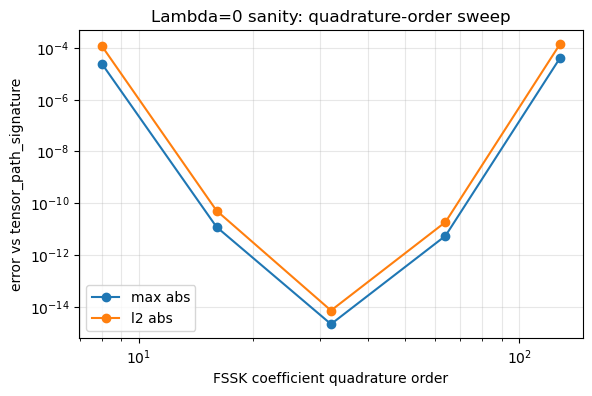

In [7]:
A_lambda0 = jnp.array([[
    [1.0, 0.25],
    [-0.15, 0.8],
]], dtype=dtype)

b_lambda0 = jnp.array([[0.7, -0.2, 1.1]], dtype=dtype)  # alpha = 1.6
R_lambda0 = b_lambda0.shape[1]

kernel_lambda0_projected = FSSK.from_matrix(
    Lambda=jnp.zeros((R_lambda0, R_lambda0), dtype=dtype),
    A=A_lambda0,
    b=b_lambda0,
    quad_order=64,
)

lambda0_total_projected, lambda0_levels_projected, sig_projected, fssk_projected, states_projected = (
    run_lambda0_signature_sanity(
        X_lambda0,
        kernel_lambda0_projected,
        dt,
        trunc=trunc,
        label="Lambda=0, projected/scaled",
    )
)

display(lambda0_total_projected)
display(lambda0_levels_projected)

# Optional: check whether any mismatch is quadrature-order dependent.
quad_sweep_lambda0 = lambda0_quad_order_sweep(
    X_lambda0,
    A=A_lambda0,
    b=b_lambda0,
    dt=dt,
    trunc=trunc,
    orders=(8, 16, 32, 64, 128),
)
display(quad_sweep_lambda0)

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.loglog(quad_sweep_lambda0["quad_order"], quad_sweep_lambda0["max_abs"], marker="o", label="max abs")
ax.loglog(quad_sweep_lambda0["quad_order"], quad_sweep_lambda0["l2_abs"], marker="o", label="l2 abs")
ax.set_xlabel("FSSK coefficient quadrature order")
ax.set_ylabel("error vs tensor_path_signature")
ax.set_title("Lambda=0 sanity: quadrature-order sweep")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


## Example 1: scalar `R=1`, `m=d=1`

This is the first sanity check. There is no transpose ambiguity.

,max_abs,l2_abs,rel_l2,micro_steps,drift
0,1.875749e-02,3.209014e-02,1.186002e-02,4,paper
1,9.190902e-03,1.578475e-02,5.833799e-03,8,paper
2,4.549701e-03,7.829130e-03,2.893525e-03,16,paper
3,2.263560e-03,3.898973e-03,1.441000e-03,32,paper
4,1.128975e-03,1.945616e-03,7.190693e-04,64,paper
5,5.637887e-04,9.718434e-04,3.591782e-04,128,paper
6,6.874002e-08,1.185063e-07,4.379810e-08,1048576,paper


,micro_steps,drift,level,max_abs,l2_abs,rel_l2,label
0,4,paper,0,0.000000,0.000000,0.000000,M=4
1,4,paper,1,0.004487,0.007843,0.007843,M=4
2,4,paper,2,0.018757,0.030000,0.030000,M=4
3,4,paper,3,0.006979,0.008263,0.008263,M=4
20,128,paper,0,0.000000,0.000000,0.000000,M=128
21,128,paper,1,0.000138,0.000240,0.000240,M=128
22,128,paper,2,0.000564,0.000902,0.000902,M=128
23,128,paper,3,0.000225,0.000272,0.000272,M=128


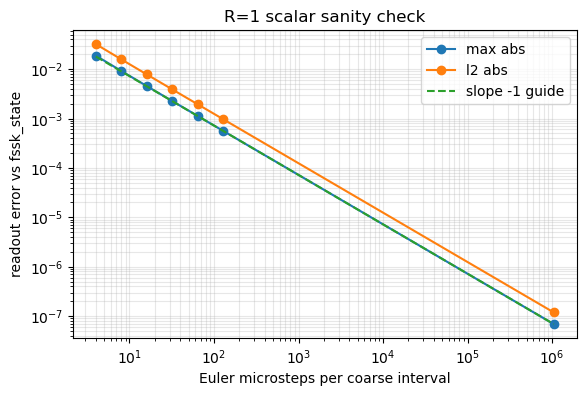

In [8]:
dtype = jnp.float64
trunc = 3
S = 6
T = 1.0

t = jnp.linspace(0.0, T, S + 1, dtype=dtype)
X_scalar = (0.35 * t + 0.2 * jnp.sin(2.0 * jnp.pi * t))[:, None]
dt = T / S

kernel_scalar = FSSK.from_matrix(
    Lambda=jnp.array([[0.8]], dtype=dtype),
    A=jnp.array([[[1.0]]], dtype=dtype),
    b=jnp.array([[1.3]], dtype=dtype),
    quad_order=32,
)

df_scalar, levels_scalar, exact_scalar, states_scalar = run_convergence_q1(
    X_scalar,
    kernel_scalar,
    dt,
    trunc=trunc,
    micro_steps_list=(4, 8, 16, 32, 64, 128,2**20),
    drift_convention="paper",
)

display(df_scalar)
display(levels_scalar[levels_scalar["micro_steps"].isin([4, 128])])
plot_convergence(df_scalar, title="R=1 scalar sanity check");

## Example 2: diagonal `R=2`, nontrivial `m=d=2`

This checks multi-factor behavior while still avoiding non-diagonal transpose ambiguity.

,max_abs,l2_abs,rel_l2,micro_steps,drift
0,4.619406e-03,1.446992e-02,5.001398e-03,4,paper
1,2.294618e-03,7.207184e-03,2.491098e-03,8,paper
2,1.143517e-03,3.596603e-03,1.243134e-03,16,paper
3,5.708079e-04,1.796550e-03,6.209613e-04,32,paper
4,2.851661e-04,8.978363e-04,3.103290e-04,64,paper
5,1.425235e-04,4.488084e-04,1.551266e-04,128,paper
6,1.739285e-08,5.476577e-08,1.892930e-08,1048576,paper


,micro_steps,drift,level,max_abs,l2_abs,rel_l2,label
0,4,paper,0,0.000000,0.000000,0.000000,M=4
1,4,paper,1,0.001423,0.003184,0.003184,M=4
2,4,paper,2,0.004619,0.013576,0.013576,M=4
3,4,paper,3,0.001458,0.003863,0.003863,M=4
20,128,paper,0,0.000000,0.000000,0.000000,M=128
21,128,paper,1,0.000045,0.000099,0.000099,M=128
22,128,paper,2,0.000143,0.000419,0.000419,M=128
23,128,paper,3,0.000047,0.000126,0.000126,M=128


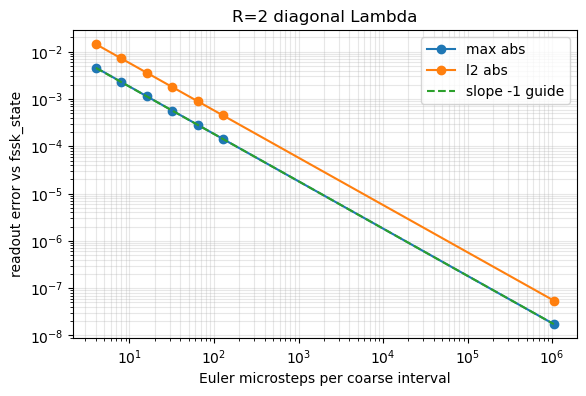

In [9]:
trunc = 3
S = 7
T = 1.0

t = jnp.linspace(0.0, T, S + 1, dtype=dtype)
X_2d = jnp.stack([
    0.4 * t + 0.15 * jnp.sin(2.0 * jnp.pi * t),
    -0.2 * t + 0.1 * jnp.cos(3.0 * jnp.pi * t),
], axis=-1)
dt = T / S

kernel_diag = FSSK.from_matrix(
    Lambda=jnp.diag(jnp.array([0.5, 1.4], dtype=dtype)),
    A=jnp.array([[[1.0, 0.25], [-0.15, 0.8]]], dtype=dtype),
    b=jnp.array([[1.2, -0.35]], dtype=dtype),
    quad_order=32,
)

df_diag, levels_diag, exact_diag, states_diag = run_convergence_q1(
    X_2d,
    kernel_diag,
    dt,
    trunc=trunc,
    micro_steps_list=(4, 8, 16, 32, 64, 128, 2**20),
    drift_convention="paper",
)

display(df_diag)
display(levels_diag[levels_diag["micro_steps"].isin([4, 128])])
plot_convergence(df_diag, title="R=2 diagonal Lambda");

## Example 3: non-diagonal `Lambda`, drift-orientation diagnostic

For a genuinely non-diagonal matrix, compare both conventions:

- `paper`: the ODE as stated in `i_part.tex`.
- `state_right`: transposed drift diagnostic.

Expected outcome: the mathematically correct implementation should converge under `paper`. If only `state_right` converges, that points to a transpose mismatch somewhere in the state/readout convention.

,max_abs,l2_abs,rel_l2,micro_steps,drift
0,0.002779,0.010828,0.003777,4,paper
1,0.001375,0.005325,0.001857,8,paper
2,0.000684,0.002641,0.000921,16,paper
3,0.000341,0.001315,0.000459,32,paper
4,0.000170,0.000656,0.000229,64,paper
5,0.000085,0.000328,0.000114,128,paper
6,0.057233,0.126402,0.044093,4,state_right
7,0.056314,0.124957,0.043588,8,state_right
8,0.055856,0.124369,0.043383,16,state_right
9,0.055627,0.124108,0.043292,32,state_right


,micro_steps,drift,level,max_abs,l2_abs,rel_l2,label
0,4,paper,0,0.000000,0.000000,0.000000,M=4
1,4,paper,1,0.002779,0.006133,0.006133,M=4
2,4,paper,2,0.002626,0.008642,0.008642,M=4
3,4,paper,3,0.000785,0.002227,0.002227,M=4
20,128,paper,0,0.000000,0.000000,0.000000,M=128
21,128,paper,1,0.000085,0.000188,0.000188,M=128
22,128,paper,2,0.000079,0.000259,0.000259,M=128
23,128,paper,3,0.000024,0.000070,0.000070,M=128
24,4,state_right,0,0.000000,0.000000,0.000000,M=4
25,4,state_right,1,0.057233,0.125538,0.125538,M=4


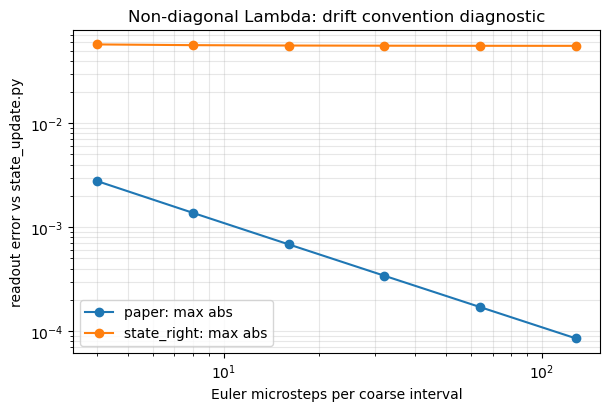

In [10]:
kernel_nondiag = FSSK.from_matrix(
    Lambda=jnp.array([[0.8, -0.25], [0.15, 1.1]], dtype=dtype),
    A=jnp.array([[[1.0, 0.25], [-0.15, 0.8]]], dtype=dtype),
    b=jnp.array([[1.2, -0.35]], dtype=dtype),
    quad_order=32,
)

conv_tables = []
level_tables = []
for drift in ["paper", "state_right"]:
    df, lev, exact_nd, states_nd = run_convergence_q1(
        X_2d,
        kernel_nondiag,
        dt,
        trunc=trunc,
        micro_steps_list=(4, 8, 16, 32, 64, 128),
        drift_convention=drift,
    )
    conv_tables.append(df)
    level_tables.append(lev)

conv_nondiag = pd.concat(conv_tables, ignore_index=True)
levels_nondiag = pd.concat(level_tables, ignore_index=True)

display(conv_nondiag)
display(levels_nondiag[levels_nondiag["micro_steps"].isin([4, 128])])

fig, ax = plt.subplots(figsize=(6.8, 4.2))
for drift, sub in conv_nondiag.groupby("drift"):
    ax.loglog(sub["micro_steps"], sub["max_abs"], marker="o", label=f"{drift}: max abs")
ax.set_xlabel("Euler microsteps per coarse interval")
ax.set_ylabel("readout error vs state_update.py")
ax.set_title("Non-diagonal Lambda: drift convention diagnostic")
ax.grid(True, which="both", alpha=0.3)
ax.legend();

## Optional: inspect a single level directly

This is useful when the total error is not enough to see whether the mismatch starts at level 1 or only appears in higher tensor levels.

In [14]:
M = 128
Lambda_mat = lambda_matrix_from_backend(kernel_nondiag, dtype=dtype)
exact_readout, _ = fssk_exact_readout_q1(X_2d, kernel_nondiag, dt, trunc)

euler_paper = euler_ode_readout_q1(
    X_2d, dt,
    Lambda_mat=Lambda_mat,
    A=kernel_nondiag.A[0],
    b=kernel_nondiag.b[0],
    trunc=trunc,
    micro_steps=M,
    drift_convention="paper",
)

euler_state_right = euler_ode_readout_q1(
    X_2d, dt,
    Lambda_mat=Lambda_mat,
    A=kernel_nondiag.A[0],
    b=kernel_nondiag.b[0],
    trunc=trunc,
    micro_steps=M,
    drift_convention="state_right",
)

level = 1
print("exact final level", level, np.asarray(exact_readout[level][-1]))
print("paper Euler final level", level, np.asarray(euler_paper[level][-1]))
print("state_right Euler final level", level, np.asarray(euler_state_right[level][-1]))

exact final level 1 [ 0.17100445 -0.21225398]
paper Euler final level 1 [ 0.17107048 -0.21233159]
state_right Euler final level 1 [ 0.210893  -0.2677094]


## Optional: future readout from a `state.py` state

For a lag `ell = tau - t >= 0`, the finite-state recursion readout is

```text
1 + Z_t @ (exp(-Lambda * ell) @ b).
```

This checks more of the hidden state than the current-time readout. The ODE side below propagates the Euler state over the same lag with zero input using the `lambdas.py` exponential action.

In [15]:
# Future readout: apply fssk_readout with a non-zero tau_dt lag.
# fssk_readout handles arbitrary batch shapes, so passing the full
# trajectory state or a single terminal state both work.

def pure_mean_revert_ode_state_paper(Z_at_t, kernel, lag):
    """Exact zero-input propagation for the paper convention using lambdas.py expm_multiply_left."""
    return tuple(kernel.Lambda.expm_multiply_left(lag, z, dtype=z.dtype) for z in Z_at_t)


lag = jnp.array(0.25, dtype=dtype)
state_py_final = tuple(z[-1] for z in states_diag)  # terminal first-on state

# Use fssk_readout directly with tau_dt=lag instead of the old manual helper.
fssk_future = fssk_readout(state_py_final, kernel=kernel_diag, tau_dt=lag)

Z_ode_all = euler_ode_states_q1(
    X_2d,
    dt,
    Lambda_mat=lambda_matrix_from_backend(kernel_diag, dtype=dtype),
    A=kernel_diag.A[0],
    b=kernel_diag.b[0],
    trunc=trunc,
    micro_steps=128,
    drift_convention="paper",
)
Z_ode_future = pure_mean_revert_ode_state_paper(tuple(z[-1] for z in Z_ode_all), kernel_diag, lag)
ode_future = _state_signature_readout_levels(Z_ode_future)

display(dense_elem_error_table(fssk_future, ode_future, label=f"lag={float(lag):.2f}"))


,level,max_abs,l2_abs,rel_l2,label
0,0,0.000000,0.000000,0.000000,lag=0.25
1,1,0.000046,0.000057,0.000057,lag=0.25
2,2,0.000131,0.000225,0.000225,lag=0.25
3,3,0.000044,0.000094,0.000094,lag=0.25
